In [1]:
# This notebook will record the results of the simulation and all the KPIs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Hello World")


Hello World


In [85]:
def list_processes(df: pd.DataFrame) -> list[str]:
    """Identify processes from timestamp columns named '<Process> Queue'.

    A process is detected when both '<Process> Queue' and '<Process> Start'
    columns are present. Returns lowercase process slugs in column order.

    Examples
    --------
    Patient df  -> ['screening', 'reporting']
    Slide df    -> ['fixation', 'staining']
    """
    cols = [c.strip() for c in df.columns]
    processes = []
    seen = set()

    for col in cols:
        if not col.endswith(' Queue'):
            continue
        process_name = col[:-len(' Queue')]
        if f'{process_name} Start' not in cols:
            continue
        slug = process_name.lower()
        if slug not in seen:
            processes.append(slug)
            seen.add(slug)

    return processes

In [ ]:
def load_waiting_times(path=None, df=None):
    """Load waiting times from patient or slide simulation results."""
    if df is None:
        if path is None:
            raise ValueError("Provide either path or df")
        df = pd.read_csv(path, skipinitialspace=True)

    df = df.copy()
    df.columns = df.columns.str.strip()

    processes = list_processes(df)
    if not processes:
        raise ValueError("No processes found: expected '<Process> Queue' and '<Process> Start' columns")

    col_map = {c.lower(): c for c in df.columns}

    def _parse_datetime_cols(cols):
        for col in cols:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .replace('N/A', pd.NA)
            )
            df[col] = pd.to_datetime(df[col], errors='coerce')

    datetime_cols = []
    for process in processes:
        datetime_cols.extend([col_map[f'{process} queue'], col_map[f'{process} start']])
    _parse_datetime_cols(datetime_cols)

    for process in processes:
        queue_col = col_map[f'{process} queue']
        start_col = col_map[f'{process} start']
        df[f'waiting_for_{process}_days'] = (
            df[start_col] - df[queue_col]
        ).dt.total_seconds() / (24 * 3600)

    return df

In [59]:
def plot_waiting_times(df:pd.DataFrame, process_name:str, group_name:str = None):
    """ This function plots waiting times for a given process and group name if provided
    df : pd.DataFrame - the simulation results
    process_name : str - the process name
    group_name : str - the group name - Optional
    """
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.plot(df.index, df[f'waiting_for_{process_name}_days'], linewidth=1, alpha=0.7, color='steelblue')
    ax.set_ylabel('Waiting Time (days)')
    ax.set_title(f'Waiting Time for {process_name}', fontweight='bold')
    ax.grid(True, alpha=0.3)  
    ax.title.set_text(f'Waiting Time for {process_name} and {group_name} patients')
    ax.set_xlabel('Patient Number')
    ax.set_ylabel('Waiting Time (days)')
    plt.show()
    return fig, ax
  


In [ ]:
def analyse_wait_times(filepath=None, df=None, group_name: str = None):
    """Plot waiting times for all processes detected in the data.

    Provide either filepath or df. Processes are detected automatically
    from '<Process> Queue' / '<Process> Start' column pairs.
    """
    if df is None and filepath is None:
        raise ValueError("Provide either filepath or df")

    wait_df = load_waiting_times(path=filepath, df=df)

    for process in list_processes(wait_df):
        plot_waiting_times(wait_df, process, group_name)
        print(wait_df[f'waiting_for_{process}_days'].describe())

    return wait_df



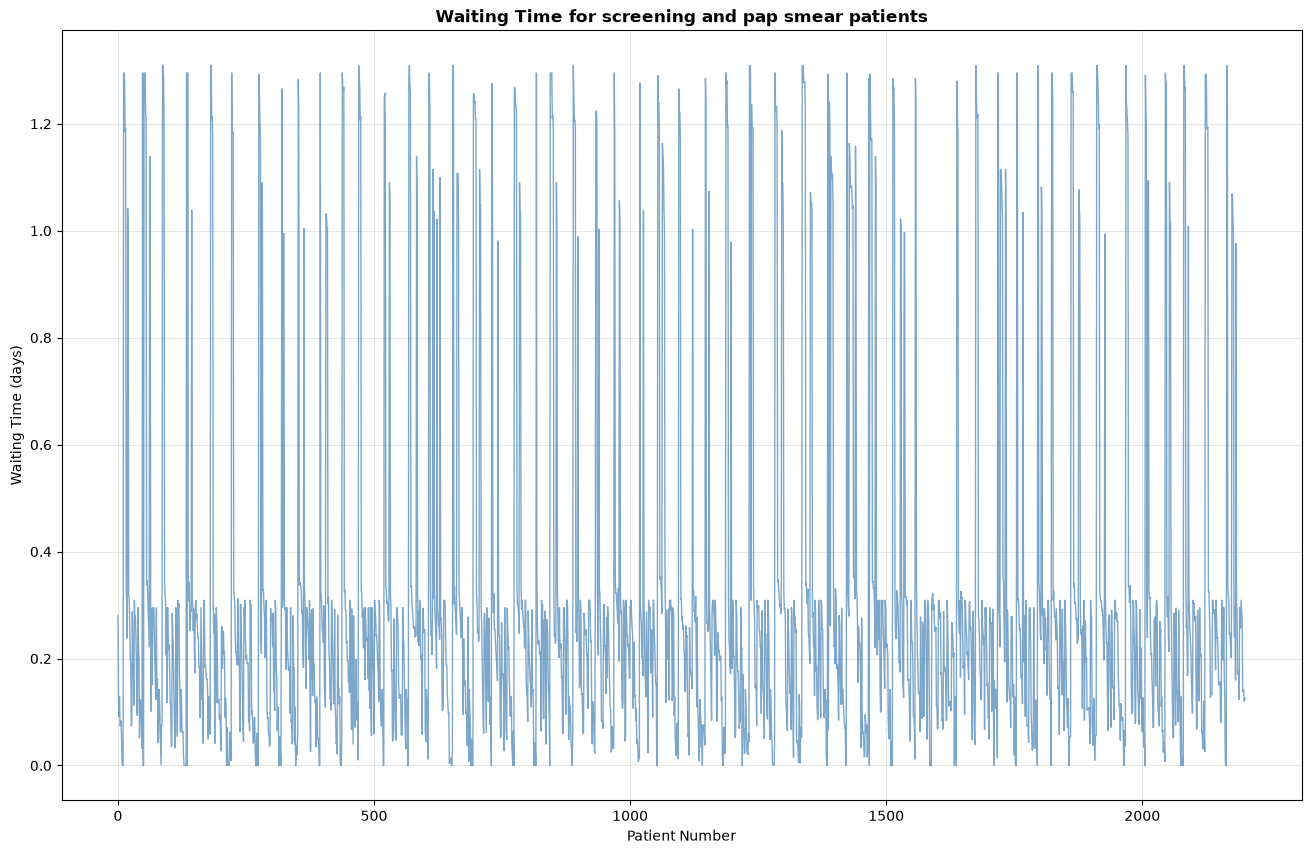

count    2202.000000
mean        0.316843
std         0.353958
min         0.000000
25%         0.111979
50%         0.227083
75%         0.301389
max         1.309028
Name: waiting_for_screening_days, dtype: float64


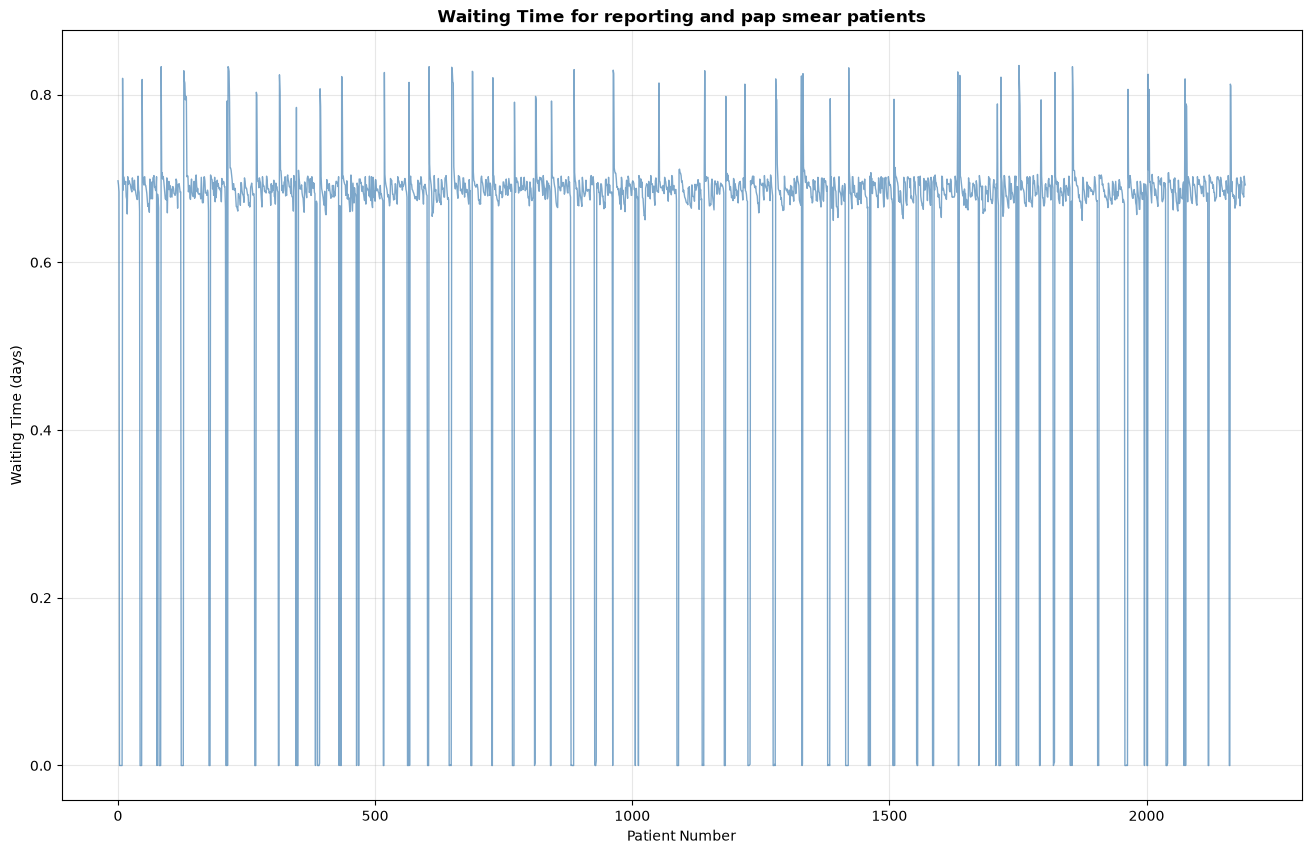

count    2193.000000
mean        0.636853
std         0.187416
min         0.000000
25%         0.676389
50%         0.686806
75%         0.695139
max         0.834722
Name: waiting_for_reporting_days, dtype: float64


,Patient ID,Type,Arrival,Screening Queue,Screening Start,Screening End,Screening Duration (min),Reporting Queue,Reporting Start,Reporting End,Completed,waiting_for_screening_days,waiting_for_reporting_days
0,Pap-000001,pap_smear,2026-05-01 09:00,2026-05-01 10:16:00,2026-05-01 17:00:00,2026-05-01 17:16,16.99,2026-05-01 17:16:00,2026-05-02 10:00:00,2026-05-02 10:03,Yes,0.280556,0.697222
1,Pap-000002,pap_smear,2026-05-01 13:48,2026-05-01 14:43:00,2026-05-01 17:39:00,2026-05-01 17:49,9.94,2026-05-01 17:49:00,2026-05-02 10:26:00,2026-05-02 10:28,Yes,0.122222,0.692361
2,Pap-000003,pap_smear,2026-05-01 13:53,2026-05-01 15:34:00,2026-05-01 17:46:00,2026-05-01 18:09,23.76,2026-05-01 18:09:00,2026-05-02 10:34:00,2026-05-02 10:46,Yes,0.091667,0.684028
3,Pap-000004,pap_smear,2026-05-02 09:00,2026-05-02 09:55:00,2026-05-02 13:00:00,2026-05-02 13:09,9.26,2026-05-02 13:09:00,2026-05-02 13:09:00,2026-05-02 13:13,Yes,0.128472,0.000000
4,Pap-000005,pap_smear,2026-05-02 09:36,2026-05-02 11:24:00,2026-05-02 13:11:00,2026-05-02 13:25,13.59,2026-05-02 13:25:00,2026-05-02 13:25:00,2026-05-02 13:28,Yes,0.074306,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198,Pap-002199,pap_smear,2027-04-30 13:37,2027-04-30 14:35:00,2027-04-30 17:59:00,2027-04-30 18:15,15.80,2027-04-30 18:15:00,NaT,NaN,No,0.141667,NaN
2199,Pap-002200,pap_smear,2027-04-30 13:44,2027-04-30 15:10:00,2027-04-30 18:03:00,2027-04-30 18:13,9.21,2027-04-30 18:13:00,NaT,NaN,No,0.120139,NaN
2200,Pap-002201,pap_smear,2027-04-30 13:46,2027-04-30 15:10:00,2027-04-30 18:09:00,2027-04-30 18:21,11.94,2027-04-30 18:21:00,NaT,NaN,No,0.124306,NaN
2201,Pap-002202,pap_smear,2027-04-30 13:46,2027-04-30 15:10:00,2027-04-30 18:11:00,2027-04-30 18:19,8.17,2027-04-30 18:19:00,NaT,NaN,No,0.125694,NaN


In [ ]:
filepath = r'/Users/varad/Desktop/Lenovo Desktop/Oxford/DPhil Cervical Cancer Scale-up/Code/real_world_sim/sim_results/20260706_122756_simulation_patient_timestamps.csv'
df = pd.read_csv(filepath)
df_pap = df[df['Type'] == 'pap_smear']
df_non_pap = df[df['Type'] == 'non_pap_smear']

analyse_wait_times(df=df_pap, group_name = 'pap smear')

In [ ]:
# Plotting resource utilisation percentage
def plot_res_util_pct(df:pd.DataFrame):
    '''This function plots the utilisation percentage of resources'''
    
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.bar(df['utilisation_key'], df['utilisation_pct'], linewidth=1, alpha=0.7, color='steelblue')
    ax.set_ylabel('Utilisation (%)', fontsize=14)
    ax.set_xlabel('Resource', fontsize=14)
    ax.set_title(f'Utilisation % of Resources', fontsize=16)
    ax.grid(True, alpha=0.3)
    
    bars = ax.bar(df['utilisation_key'], df['utilisation_pct'], linewidth=1, alpha=0.7, color='steelblue')
    
    plt.bar_label(
    bars,
    labels=[f'{v:.1f}%' for v in df['utilisation_pct']],
    padding=3,
    fontsize=14,
    )
    plt.xticks(fontsize=14)
    plt.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.6, label='100% capacity')
    plt.ylim(0, max(100, df['utilisation_pct'].max() + 10))
    plt.tight_layout()
    plt.show()
    return fig, ax



In [106]:
def calc_res_util_pct(busy_minutes:pd.DataFrame, total_minutes:pd.DataFrame):
    """ This function calculates the utilisation percentage of resources
    busy_minutes: pd.DataFrame - the busy minutes of the resources
    total_minutes: pd.DataFrame - the total minutes of the resources
    """
    busy_minutes = busy_minutes.copy()
    busy_minutes.columns = busy_minutes.columns.str.strip()
    busy_minutes['utilisation_key'] = busy_minutes['utilisation_key'].str.strip()

    df_res_util_num_sum = (
        busy_minutes
        .groupby('utilisation_key', as_index=False)['duration_min']
        .sum()
        .sort_values('utilisation_key')
        .reset_index(drop=True)
    )

    total_minutes = total_minutes.copy()
    total_minutes.columns = total_minutes.columns.str.strip()
    total_minutes['utilisation_key'] = total_minutes['utilisation_key'].str.strip()

    
    for resource_type in total_minutes['resource_type']:
        if resource_type == 'equipment':
            resource_minutes = total_minutes.loc[
                total_minutes['resource_type'] == 'equipment',
                'scheduled_available_minutes',
            ].iloc[0]
        
            total_minutes.loc[
            total_minutes['resource_type'] == 'equipment',
            'scheduled_available_minutes',
            ] = resource_minutes

    df_res_util_den = total_minutes.merge(df_res_util_num_sum, on='utilisation_key', how='left')
    df_res_util_den['available_person_minutes'] = (
        df_res_util_den['capacity'] * df_res_util_den['scheduled_available_minutes']
    )
    df_res_util_den['utilisation_pct'] = (
    df_res_util_den['duration_min'] / df_res_util_den['available_person_minutes'] * 100
    ).round(2)
    
    df_res_util_den = df_res_util_den.sort_values('utilisation_key').reset_index(drop=True)
    print(df_res_util_den[['utilisation_key', 'utilisation_pct']])
    
    plot_res_util_pct(df_res_util_den)
    
    
    
    
    

           utilisation_key  utilisation_pct
0          Cytotechnicians            34.79
1  Junior Cytopathologists            78.78
2  Manual Staining Station            22.62
3      Senior Pathologists            25.46


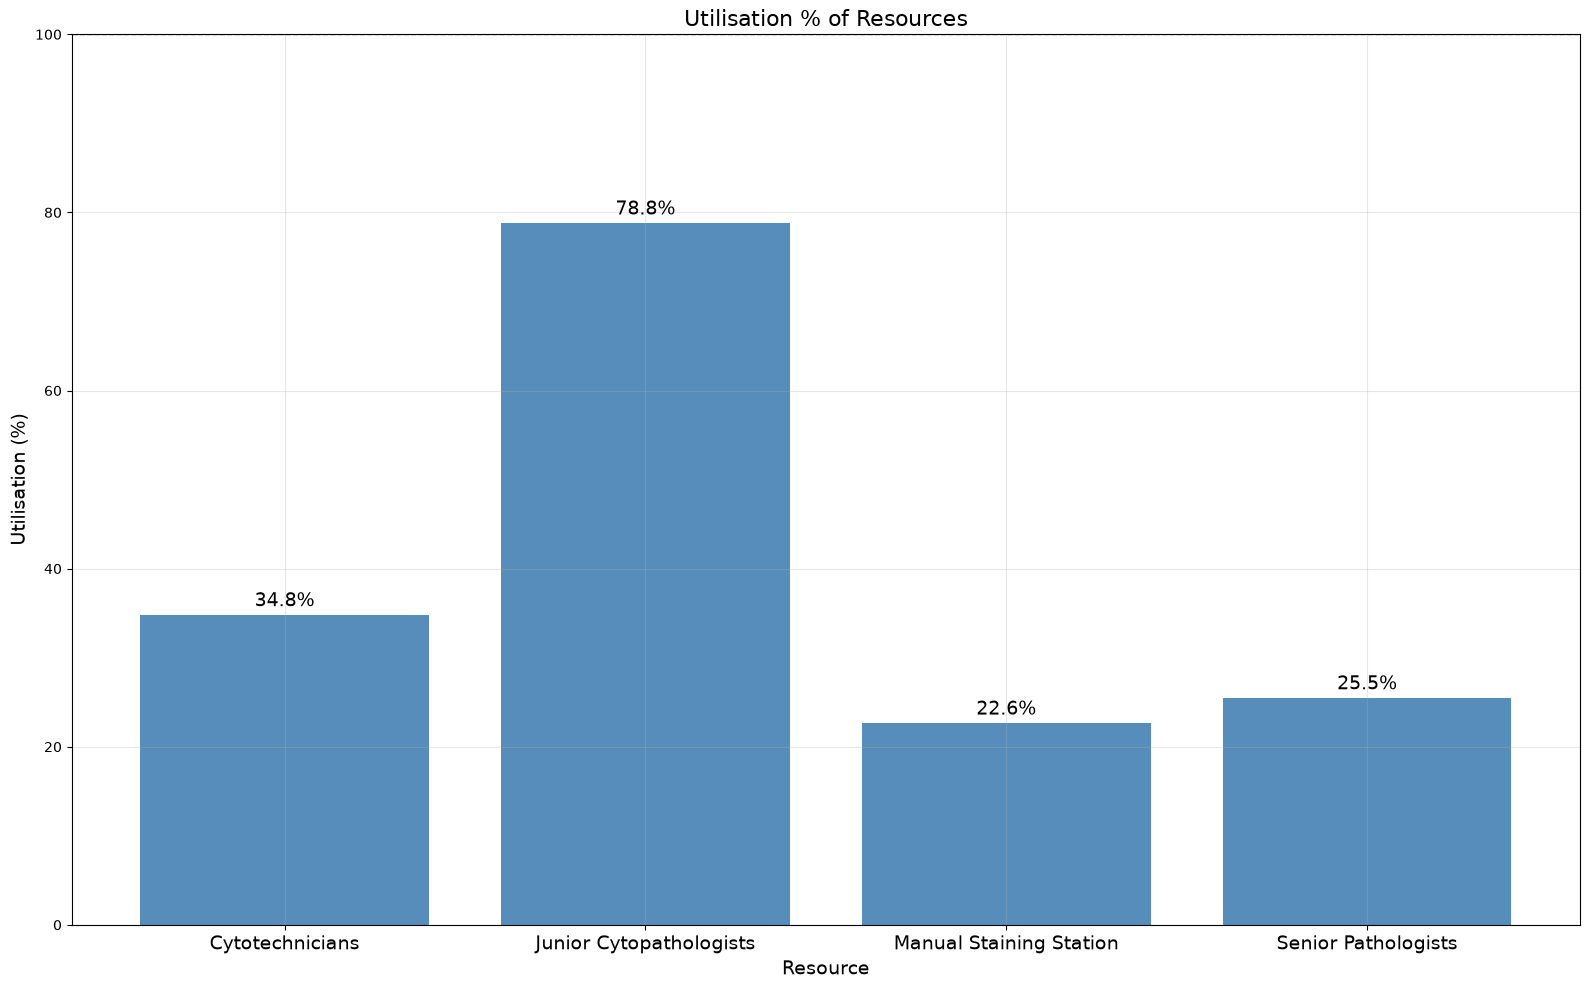

In [107]:
RUN = '20260705_174955'  # same timestamp for busy + metadata

busy = pd.read_csv(f'../sim_results/{RUN}_resource_busy_intervals.csv', skipinitialspace=True)
total = pd.read_csv(f'../sim_results/{RUN}_resource_metadata.csv', skipinitialspace=True)

total.head()

calc_res_util_pct(busy, total)


           utilisation_key  utilisation_pct
0          Cytotechnicians           119.93
1  Junior Cytopathologists           117.12
2  Manual Staining Station            39.84
3      Senior Pathologists            39.25


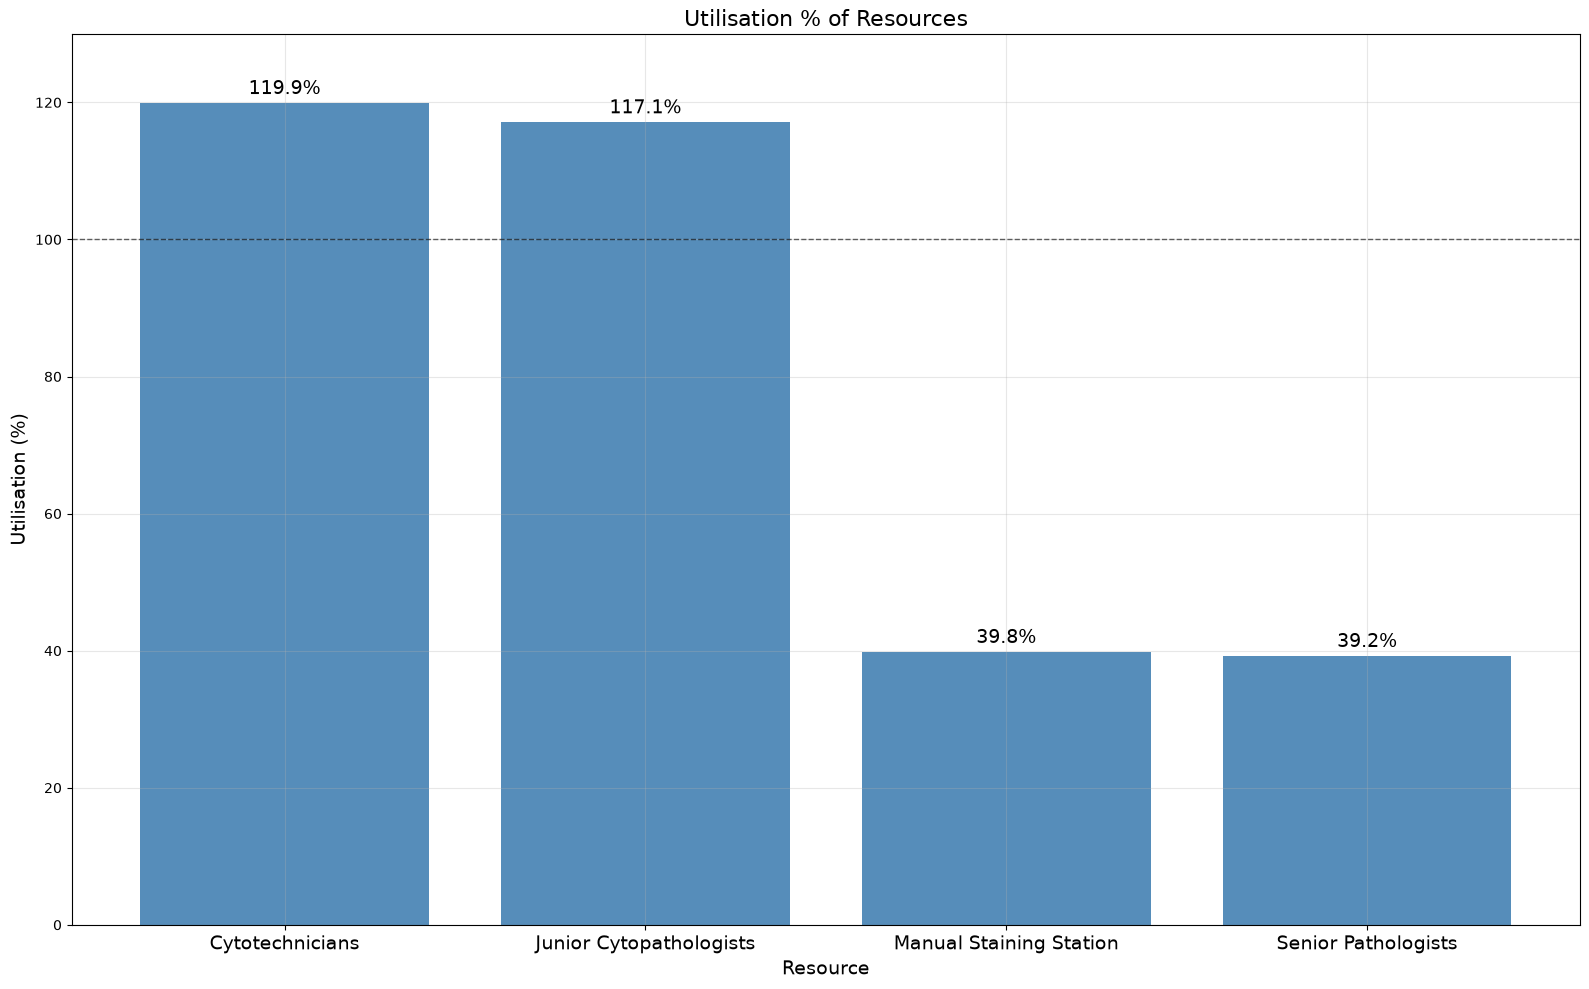

In [111]:
RUN = '20260706_113843'  # same timestamp for busy + metadata

busy = pd.read_csv(f'../sim_results/{RUN}_resource_busy_intervals.csv', skipinitialspace=True)
total = pd.read_csv(f'../sim_results/{RUN}_resource_metadata.csv', skipinitialspace=True)

total.head()

calc_res_util_pct(busy, total)
